In [4]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from fancyimpute import IterativeImputer, KNN

In [5]:
# Load the dataset
url = '/workspaces/bakery_prediction/0_DataPreparation/Processed/01_merged_data.csv'
merged_df = pd.read_csv(url)

merged_df.head()

,id,Datum,Warengruppe,Umsatz,KielerWoche,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode
0,1307011,2013-07-01,1,148.828353,NaN,6.0,17.8375,15.0,20.0
1,1307012,2013-07-01,2,535.856285,NaN,6.0,17.8375,15.0,20.0
2,1307013,2013-07-01,3,201.198426,NaN,6.0,17.8375,15.0,20.0
3,1307014,2013-07-01,4,65.890169,NaN,6.0,17.8375,15.0,20.0
4,1307015,2013-07-01,5,317.475875,NaN,6.0,17.8375,15.0,20.0


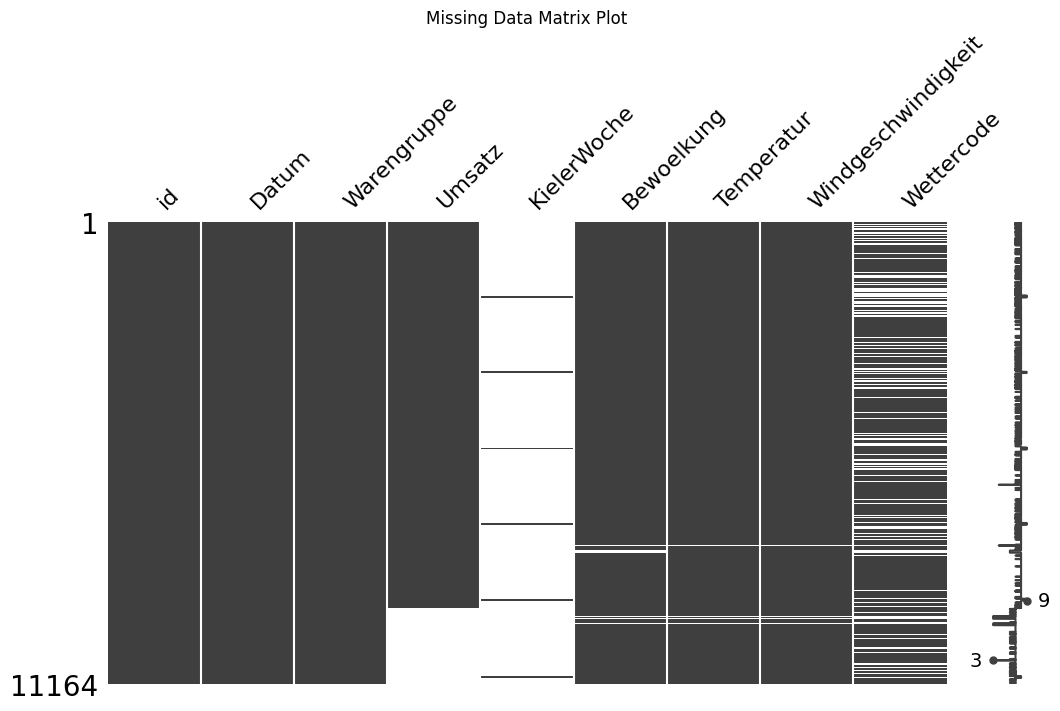

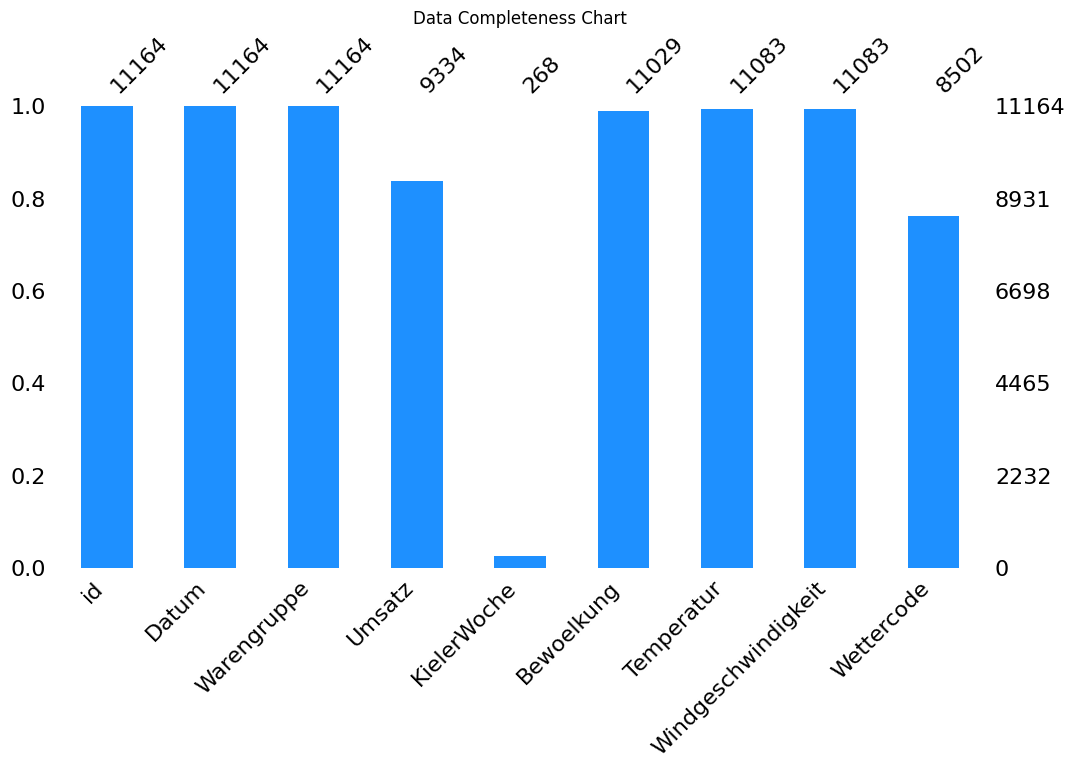

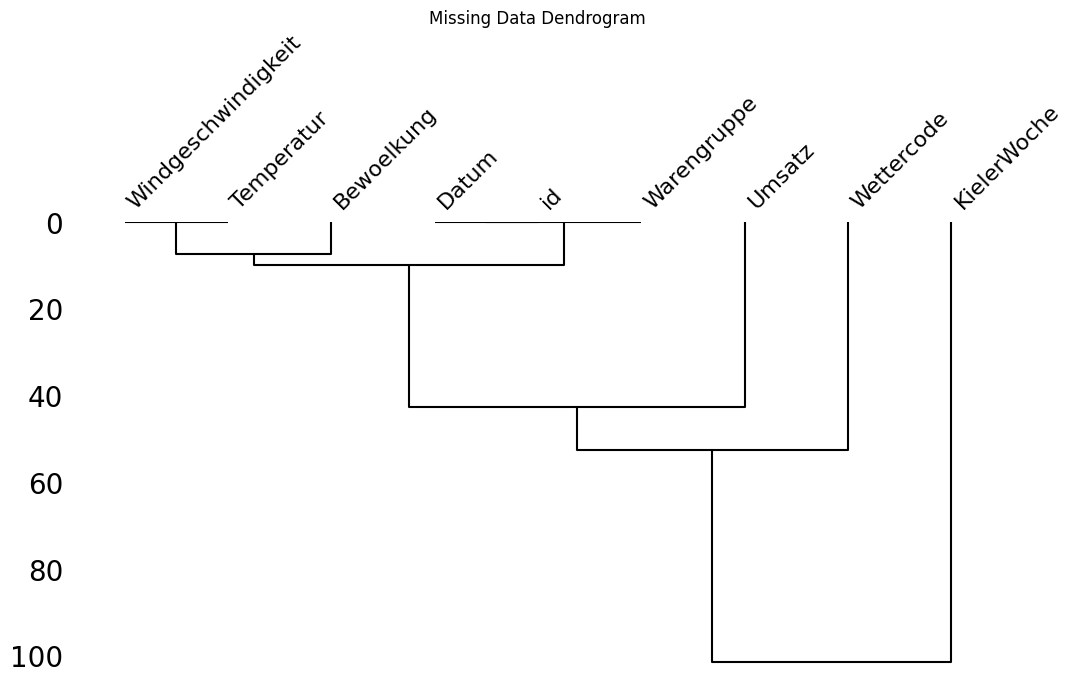

In [6]:
### Visualization of Missing Data

# Matrix plot of missing data
msno.matrix(merged_df, figsize=(12, 6))
plt.title('Missing Data Matrix Plot')
plt.show()

# Bar plot of complete data
msno.bar(merged_df, color="dodgerblue", figsize=(12, 6))
plt.title('Data Completeness Chart')
plt.show()


# Dendrogram to visualize the correlation of missingness between variables
msno.dendrogram(merged_df, figsize=(12, 6))
plt.title('Missing Data Dendrogram')
plt.show()

In [ ]:
### Imputation of Missing Data

# Create a mask for the imputed values
mask = merged_df['KielerWoche'].isna()  # mask for missing values in 'KielerWoche'

# Separate numeric and non-numeric columns
numeric_columns = merged_df.select_dtypes(include=['number'])
non_numeric_columns = merged_df.select_dtypes(exclude=['number'])

# Iterative Robust Model Imputation (IRMI)
imputer_irmi = IterativeImputer()
numeric_imputed = pd.DataFrame(imputer_irmi.fit_transform(numeric_columns), columns=numeric_columns.columns)

# Combine imputed numeric data with non-numeric data
merged_df_irmi = pd.concat([numeric_imputed, non_numeric_columns.reset_index(drop=True)], axis=1)

ValueError: could not convert string to float: '2013-07-01'

In [ ]:
### Visualization of Imputed Data

def plot_scatter_with_imputation(merged_df, merged_df_knn, x, y, mask, title='Scatter Plot', xlabel='X-axis', ylabel='Y-axis'):
    plt.figure(figsize=(10, 6))
    
    # Overall min and max for both axes
    x_min = -20
    x_max = 100
    y_min = 50
    y_max = 100
    
    # Plot points
    sns.scatterplot(x=merged_df.loc[~mask, x], y=merged_df.loc[~mask, y], color='blue', label='Original')
    sns.scatterplot(x=merged_df_knn.loc[mask, x], y=merged_df_knn.loc[mask, y], color='red', label='Imputed')

    # Set consistent axis limits
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

In [ ]:
# Plotting results for KNN imputation
plot_scatter_with_imputation(merged_df, merged_df_knn, 'KielerWoche', 'Temperatur', mask, 'KNN Imputation Scatter Plot', 'KielerWoche', 'Temperatur')


In [ ]:
### Correlation Analysis

print("Correlation in original data:", merged_df['KielerWoche'].corr(merged_df['Temperatur'], method='pearson'))
print("Correlation after KNN imputation:", merged_df_knn['KielerWoche'].corr(merged_df_knn['Temperatur']))